## 🟢 이상치

- 통계는 확률, 특이한 값들 
    직원들 평균 연봉에 등기이사님(60억)연봉 같은 경우에는 일반적인 값의 범위를 벗어난다
    특정값 범위를 벗어나는 경우에 이를 제거하거나 평균값 또는 중간값으로 대체하려 한다 

    - 1) boxplot - 이상치를 시각적으로 확인한다.
        - 최소값, 최대값, 4분위수(25%, )

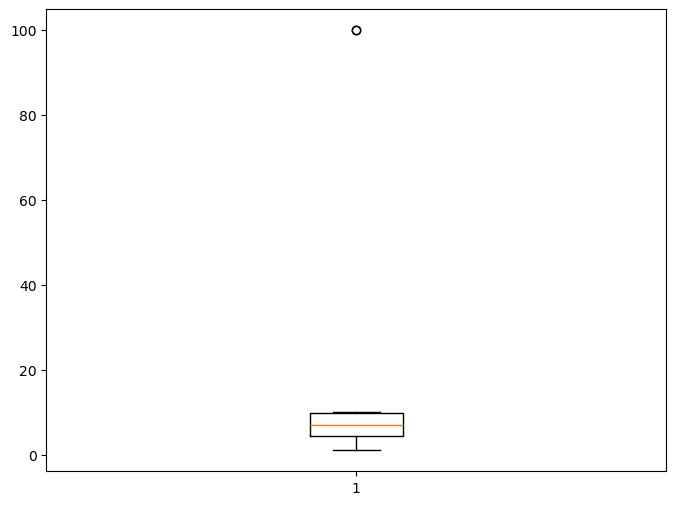

하한값 : -4.0, 상한값 : 18.0


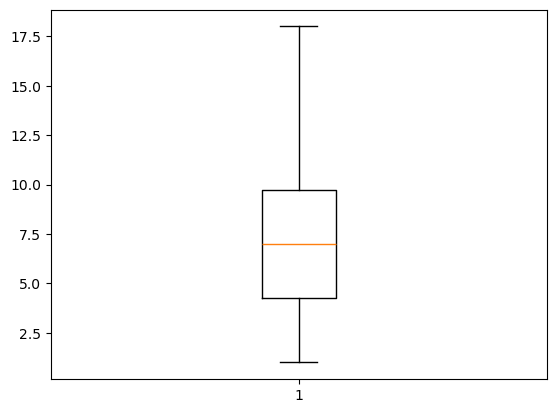

In [ ]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt

a = pd.Series([1, 2, np.nan, 4, 5, 6, np.nan, 8, 9, 10])

# 결츨치를 100으로 대체해보기
a[a.isna()] = 100

# ================================================
# boxplot 그리기 -> 보고서에 요소들의 박스 플롯
plt.figure(figsize=(8, 6))
plt.boxplot(a, vert=True)  # vert=True 세로 방향으로 그리기
plt.show()

# ================================================
# 하한 Q1
# 하한 Q3:1/4분위수 + 1.5 * (Q3 - Q1) 보다 크면 이상치
def outfliers_iqr(data):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

lower, upper = outfliers_iqr(a)
print(f"하한값 : {lower}, 상한값 : {upper}")


# ================================================
# 이상치 처리
a[a < lower] = lower  # 하한값보다 작으면 하한값으로 대체
a[a > upper] = upper  # 상한값보다 크면 상한값으로 대체


plt.boxplot(a, vert=True)  # vert-방향, True를 주면 수직으로, False면 수평
plt.show()
